<a href="https://colab.research.google.com/github/chrispchen/ChenHypoxia/blob/main/scRNA-seq%20analysis/HarmonizedUMAPsandMarkerGenes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Harmonized UMAPs and Marker gene expression
This notebook consists harmonization of cells from different conditions (normoxia, hypoxia, and reoxy), then plotting UMAPs, cell type distributions, and marker gene expression.


All mentions of 'anoxia' should be 'hypoxia'


Also several outputs had to be cleared to fit on github

## Mount google drive


In [ ]:
# Mount google drive

from google.colab import drive
drive.mount('/content/drive/')
data_path = '/content/drive/MyDrive/Chris/All/'  #change dir to your project folder

Mounted at /content/drive/


## Environment Setup

In [ ]:
# print python version to screen
!python --version

# pip install software
!pip install -q scanpy leidenalg harmonypy  pydeseq2 adjustText
!wget -qc https://raw.githubusercontent.com/wagnerde/scTools-py/master/scTools_dew.py

# import python packages
import os, sys
import numpy as np
import pandas as pd
import scanpy as sc
import scTools_dew as dew
import warnings
import seaborn as sns
import matplotlib.pyplot as plt

# set some ScanPy settings
sc.set_figure_params(dpi=120, figsize=[4,4], fontsize=7)
sc.settings.verbosity = 0

Python 3.12.13
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 122.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 131.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 101.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.9/90.9 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## Load h5ad

In [ ]:
# import for cell type labels only
adata_processed = sc.read(data_path + '/h5ad/All_annotated.h5ad')

In [ ]:
# import quality filtered dataset, process below
adata = sc.read(data_path + 'h5ad/Preprocessed.h5ad')

## Process and Normalize

In [ ]:
adata.layers['raw_nolog'] = adata.X.copy()
adata.layers['raw'] = np.log1p(adata.X.copy())
sc.pp.normalize_total(adata, target_sum=1e6, inplace=True) # TPM Normalization
adata.layers['tpm_nolog'] = adata.X.copy()
adata.layers['tpm'] = np.log1p(adata.X.copy())
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, batch_key = 'sample', n_top_genes=2000)
sc.pp.scale(adata, zero_center=False)

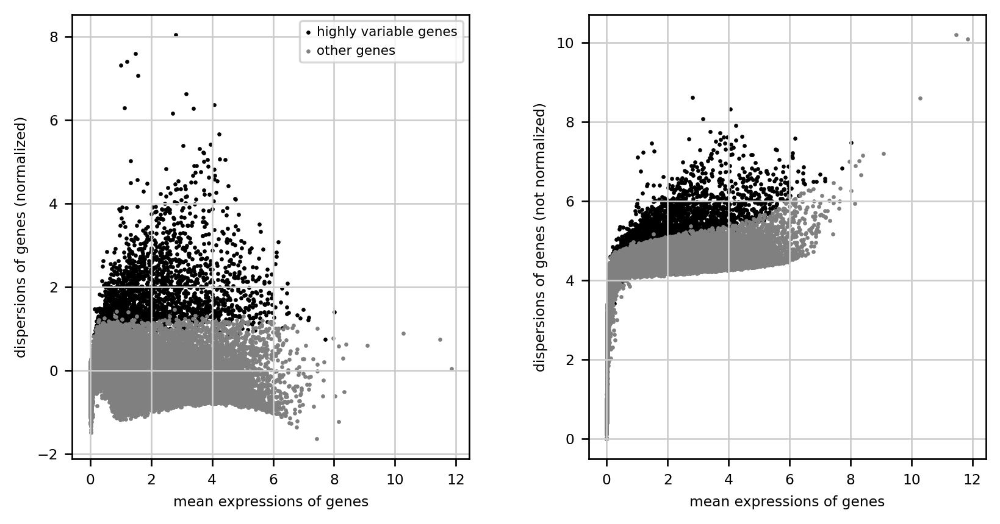

In [ ]:
#with top 2000 genes
sc.pl.highly_variable_genes(adata)

## Compute Embeddings and Perform Clustering

In [ ]:
sc.set_figure_params(dpi=120, figsize=[4,4], fontsize=7)

In other notebooks, previously determined that the number of significant PCs = ~50


In [ ]:
adata.uns['n_sig_PCs'] = 50

In [ ]:
# Perform PCA with a specified number of dimensions
sc.pp.pca(adata, n_comps=adata.uns['n_sig_PCs'])

In [ ]:
# Harmony integrate - adjust PCA embedding & generate neighbor graph
sc.external.pp.harmony_integrate(adata, 'Condition', basis='X_pca', adjusted_basis='X_pca_harmony')
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=adata.uns['n_sig_PCs'], metric='euclidean', use_rep='X_pca_harmony')

2025-11-11 01:29:03,793 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
INFO:harmonypy:Computing initial centroids with sklearn.KMeans...
2025-11-11 01:29:08,091 - harmonypy - INFO - sklearn.KMeans initialization complete.
INFO:harmonypy:sklearn.KMeans initialization complete.
2025-11-11 01:29:08,311 - harmonypy - INFO - Iteration 1 of 10
INFO:harmonypy:Iteration 1 of 10
2025-11-11 01:29:18,479 - harmonypy - INFO - Iteration 2 of 10
INFO:harmonypy:Iteration 2 of 10
2025-11-11 01:29:28,621 - harmonypy - INFO - Iteration 3 of 10
INFO:harmonypy:Iteration 3 of 10
2025-11-11 01:29:38,646 - harmonypy - INFO - Iteration 4 of 10
INFO:harmonypy:Iteration 4 of 10
2025-11-11 01:29:48,649 - harmonypy - INFO - Iteration 5 of 10
INFO:harmonypy:Iteration 5 of 10
2025-11-11 01:29:58,706 - harmonypy - INFO - Iteration 6 of 10
INFO:harmonypy:Iteration 6 of 10
2025-11-11 01:30:08,772 - harmonypy - INFO - Converged after 6 iterations
INFO:harmonypy:Converged after 6 iterations


In [ ]:
## Transfer cell type obs columns to the uniformly processed version of the data

adata = adata[adata.obs_names.isin(adata_processed.obs_names)].copy()


adata_processed = adata_processed[adata.obs_names]  # reorder adata_processed to match adata


for col in adata_processed.obs.columns:
    adata.obs[col] = adata_processed.obs[col].values

In [ ]:
# Generate embedding
sc.tl.umap(adata, n_components=2, spread=1, random_state = 12)

## Plot Embeddings

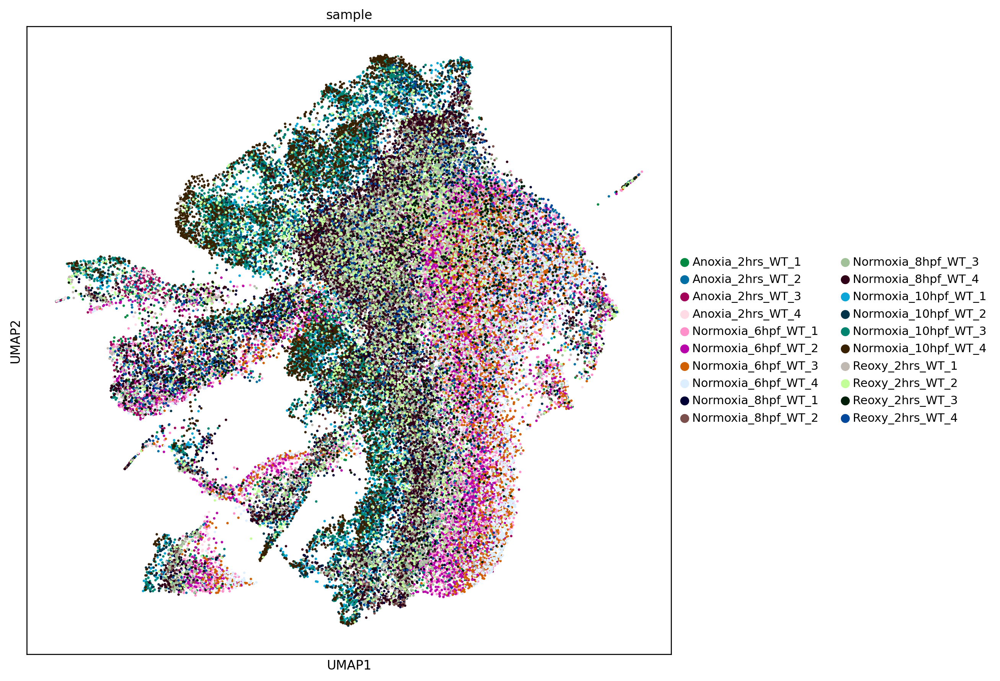

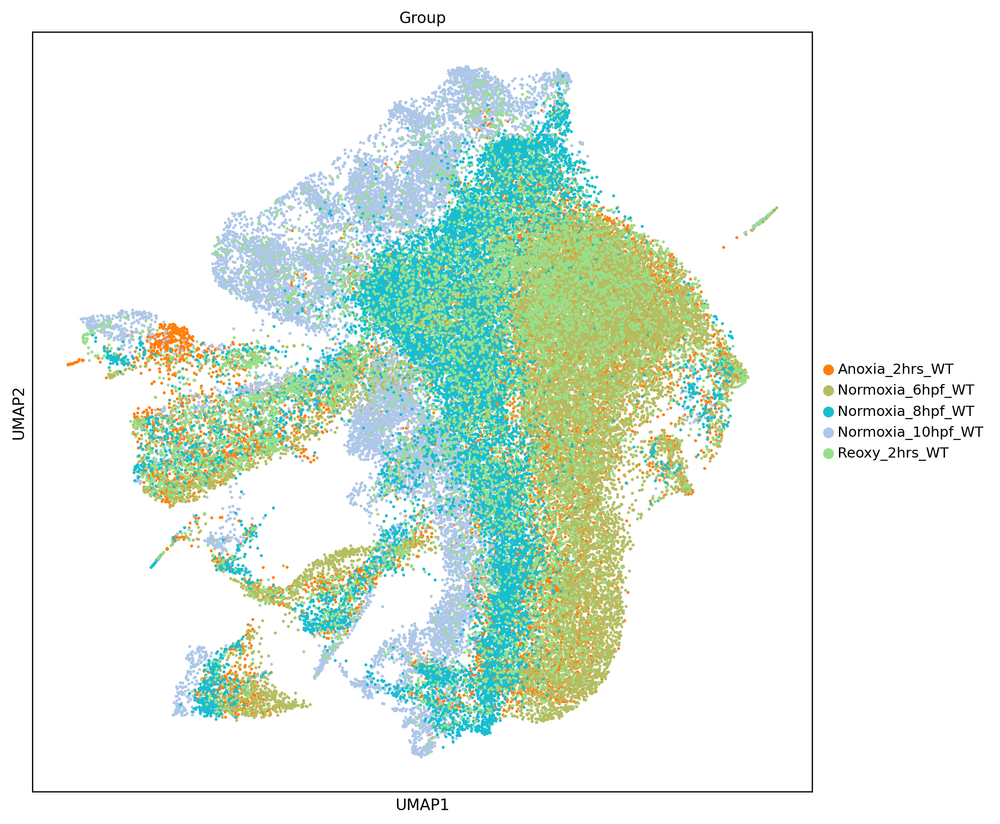

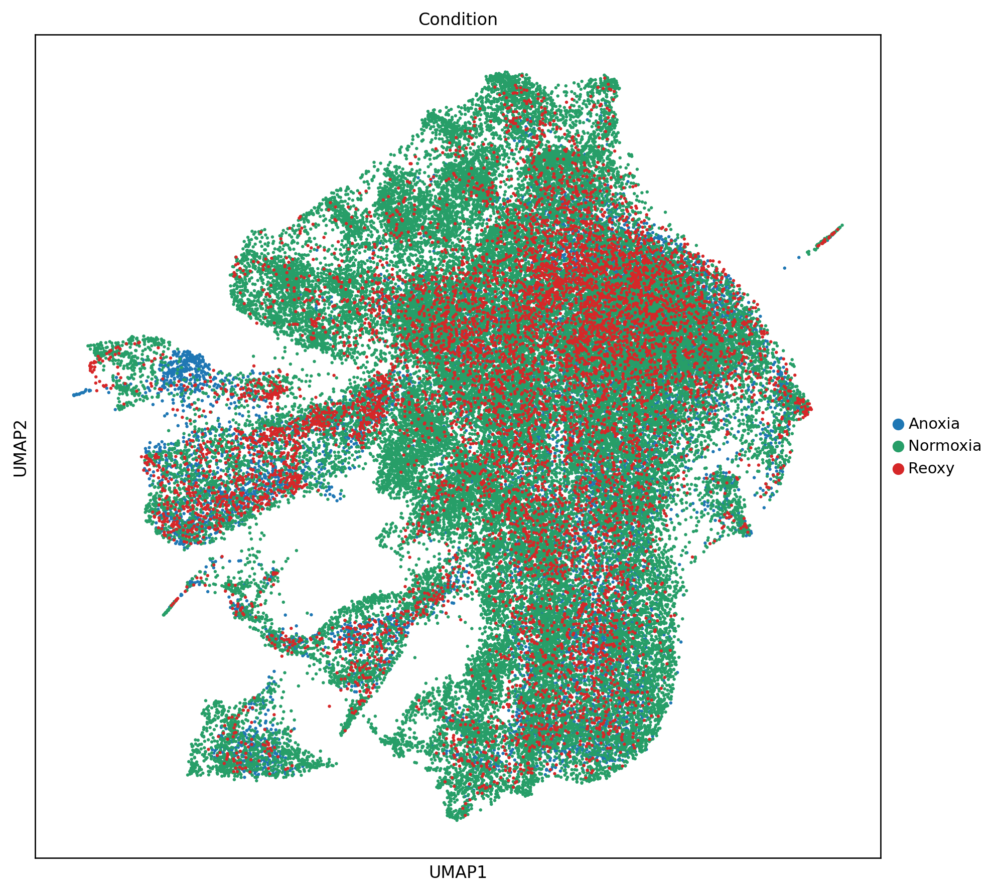

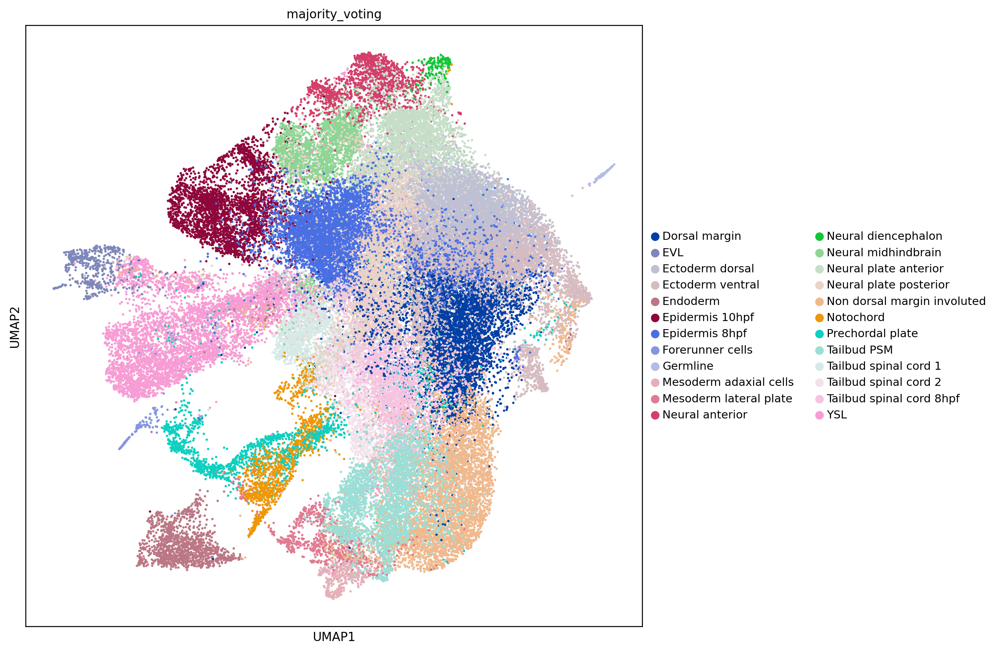

In [ ]:
sc.set_figure_params(dpi=120, figsize=[9,9], fontsize=10)

sc.pl.umap(adata, color=['sample'], size = 15)
sc.pl.umap(adata, color=['Group'], size = 15)
sc.pl.umap(adata, color=['Condition'], size = 15)
sc.pl.umap(adata, color=['majority_voting'], size = 15)

In [ ]:
sc.set_figure_params(dpi=120, figsize=[6,6], fontsize=10)

sc.pl.umap(adata, color=['sox19a', 'sox2', 'tfap2c', 'gata2a', 'tbxta', 'noto', 'dnd1', 'nanos3', 'sox32', 'cdh6', 'tbx16', 'msgn1', 'ved', 'cdx4','otx2a', 'admp', 'gsc', 'chrd','dkk1b', 'fetub', 'tfa'])

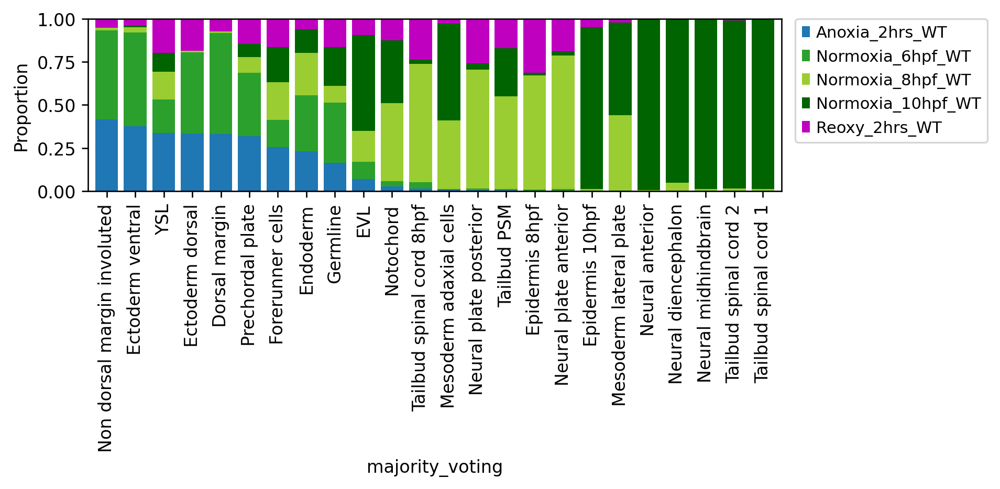

In [ ]:
# stacked barplot, order by hypoxia occupancy

import pandas as pd
import matplotlib.pyplot as plt

def plot_stacked_barplot(labels_A,
                         labels_B,
                         normalize='index',
                         fig_width=4,
                         fig_height=4,
                         colors=None,
                         sort_by=None):  # <--- add sorting option

    # Cross-tabulate the two sets of labels
    crstb = pd.crosstab(labels_A, labels_B, normalize=normalize)

    # Sort rows by a specific column if requested
    if sort_by is not None and sort_by in crstb.columns:
        crstb = crstb.sort_values(by=sort_by, ascending=False)

    # Plot stacked bars
    crstb.plot.bar(stacked=True, width=0.8, figsize=(fig_width, fig_height), color=colors)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
    plt.ylim([0, 1])
    plt.ylabel('Proportion')
    plt.grid(False)
    plt.tight_layout()
    plt.show()


# Your color dictionary
group_colors = {
    'Normoxia_6hpf_WT': '#2ca02c',
    'Normoxia_8hpf_WT': 'yellowgreen',
    'Normoxia_10hpf_WT': 'darkgreen',
    'Anoxia_2hrs_WT': '#1f77b4',
    'Reoxy_2hrs_WT': 'm'
}

# Call function, sorting by "Anoxia_2hrs_WT"
plot_stacked_barplot(
    adata.obs['majority_voting'],
    adata.obs['Group'],
    normalize='index',
    fig_width=8,
    colors=group_colors,
    sort_by='Anoxia_2hrs_WT'
)


In [ ]:
con = list(adata.obs['Group'].unique())

# Check all keys are covered — should now pass
assert all(c in group_colors for c in con), "Missing color for some conditions"

for Condition in con:
    sc.pl.umap(
        adata,
        color='Group',
        groups=[Condition],
        palette=group_colors,
        title=Condition,
        show=True, size = 15
    )


# Marker genes plot

In [ ]:
## import marker genes, from normoxic leiden clustering (see other notebooks)
markergenes = pd.read_csv(data_path + '/CPC_All_NormoxiaOnly_0_75leiden.csv')
markergenes

,Unnamed: 0,0,1,2,3,4,5,6,7,8,...,19,20,21,22,23,24,25,26,27,28
0,0,foxh1,tfap2a,lmo4a,pou5f3,tbx16,alcama,asb11,six7,mn1a,...,xbp1,col13a1,foxo3b,bbc3,ttn.1,hip1rb,LOC103911530,nkx2.1,tdrd7a,cftr
1,1,polr3gla,dlx3b,celsr1b,rasgef1ba,cyp27c1,znf385a,tcf7l1a,plxdc2,jag2b,...,foxa3,fn1a,sesn3,gadd45aa,mef2d,fhod1,CU927934.1,tet3,nanos3,dnah5
2,2,marcksl1b,klf2b,chrd,LOC110438472,snai1a,lama5,stm,otx1,nova2,...,ndr2,cxcl12a,mdm2,foxo3b,unc45b,acaca,CU927934.3,ek1,dnd1,syne1b
3,3,asb11,kctd15a,hyal2b,lrwd1,nckap5l,fat2,rgs3b,otx2b,mdkb,...,kirrel3l,pdgfra,rbl2,cdkn1a,myod1,znf185,pou5f3,epha4a,ca15b,pkd1l1
4,4,cxcr4b,tfap2c,ctnnal1,etv4,aldh1a2,rarga,aldob,fezf2,gli3,...,rrbp1b,cdh11,ccng1,rbl2,ppargc1a,krt5,lrwd1,ptch2,ddx4,CABZ01055306.1
5,5,lrwd1,prdm1a,col4a5,foxd5,hspa12a,pcdh19,sall4,sfrp1a,greb1l,...,frzb,snai1b,rnf169,fosab,sulf1,ppl,fbxo5,hipk3b,slc16a3,bicc2
6,6,cited4b,yap1,nova2,add3b,zswim5,grhl2b,mex3b,pkdcca,ncam1a,...,nrip1a,cxcl12b,abcc5,phlda3,fxr2,mboat1,ctcf,epha7,gra,ccdc13
7,7,pou5f3,esrp1,meis2b,vrtn,flrt3,tp63,pou5f3,otx2a,BX284638.1,...,elovl6,lsp1,LOC100537178,si:ch211-260e23.9,smyd1b,nrg1,add3b,fezf2,si:ch211-241j12.3,foxj1a
8,8,ctcf,gata2a,znf423,ctcf,kirrel3l,itga3b,zic3,pax6b,tenm4,...,lhx1a,notch2,slc4a2a,LOC100537178,myf5,myo5b,polr3gla,nkx2.4b,h1m,dnah7
9,9,add3b,foxi1,mdkb,cxcr4b,abi1b,bcam,sfrp1a,cyp26a1,msi1,...,fbln2,kank2,tanc1b,gadd45bb,rbfox1l,afap1l2,ddx5,ephb3a,ppp1r12a,daam1b


In [ ]:
# for annotating the marker gene csv

anon_to_new = {
    '0': 'Ectoderm ventral',
    '1': 'Epidermis 8hpf',
    '2': 'Neural plate posterior',
    '3': 'Dorsal margin',
    '4': 'Non dorsal margin involuted',
    '5': 'Epidermis 10hpf',
    '6': 'Ectoderm dorsal',
    '7': 'Neural plate anterior',
    '8': 'Neural midhindbrain',
    '9': 'Tailbud PSM 1',
    '10': 'Tailbud spinal cord 1',
    '11': 'YSL',
    '12': 'Tailbud spinal cord 2',
    '13': 'Tailbud spinal cord 8hpf',
    '14': 'Neural anterior',
    '15': 'Not sure 1',
    '16': 'Tailbud PSM 2',
    '17': 'Notochord',
    '18': 'Endoderm',
    '19': 'Prechordal plate',
    '20': 'Mesoderm lateral plate',
    '21': 'Apototic like 1',
    '22': 'Apoptotic like 2',
    '23': 'Mesoderm adaxial cells',
    '24': 'EVL',
    '25': 'Not sure 2',
    '26': 'Neural diencephalon',
    '27': 'Germline',
    '28': 'Forerunner cells'
}



In [ ]:
# subset to pertinent and abundnant cell types
# we captured cell types that did not exist in paused/reoxy states (ie from normoxia 10 hpf, they're too old)

selected_majority_groups = [ 'Dorsal margin','EVL', 'Ectoderm dorsal', 'Ectoderm ventral','Endoderm', 'Forerunner cells', 'Germline', 'Neural plate anterior', 'Non dorsal margin involuted', 'Notochord', 'Prechordal plate', 'YSL']


sliceindex = adata.obs['majority_voting'].isin(selected_majority_groups)
adata = adata[sliceindex].copy()


In [ ]:
markergenes.columns = markergenes.columns.astype(str)

In [ ]:
markergenes = markergenes.rename(columns=anon_to_new)

In [ ]:
markergenes = markergenes[selected_majority_groups]

In [ ]:
markergenes

,Dorsal margin,EVL,Ectoderm dorsal,Ectoderm ventral,Endoderm,Forerunner cells,Germline,Neural plate anterior,Notochord,Prechordal plate,YSL,Non dorsal margin involuted
0,pou5f3,hip1rb,asb11,foxh1,gpm6ab,cftr,tdrd7a,six7,epha4a,xbp1,tfa,tbx16
1,rasgef1ba,fhod1,tcf7l1a,polr3gla,cdh6,dnah5,nanos3,plxdc2,fndc3ba,foxa3,fetub,cyp27c1
2,LOC110438472,acaca,stm,marcksl1b,sox17,syne1b,dnd1,otx1,plod2,ndr2,pcxb,snai1a
3,lrwd1,znf185,rgs3b,asb11,sox32,pkd1l1,ca15b,otx2b,ppp1r14c,kirrel3l,pck2,nckap5l
4,etv4,krt5,aldob,cxcr4b,gata5,CABZ01055306.1,ddx4,fezf2,rrbp1b,rrbp1b,cdh6,aldh1a2
5,foxd5,ppl,sall4,lrwd1,prex1,bicc2,slc16a3,sfrp1a,foxa2,frzb,macf1a,hspa12a
6,add3b,mboat1,mex3b,cited4b,flrt3,ccdc13,gra,pkdcca,shha,nrip1a,abca1b,zswim5
7,vrtn,nrg1,pou5f3,pou5f3,plpp3,foxj1a,si:ch211-241j12.3,otx2a,creb3l1,elovl6,mia2,flrt3
8,ctcf,myo5b,zic3,ctcf,lzts2a,dnah7,h1m,pax6b,col15a1a,lhx1a,apobb.1,kirrel3l
9,cxcr4b,afap1l2,sfrp1a,add3b,phldb1b,daam1b,ppp1r12a,cyp26a1,itga6a,fbln2,plxna3,abi1b


In [ ]:
## Get top 3 genes for each cell type

group_markers = {}
for cluster in markergenes.columns:
    genes = markergenes.loc[:, cluster].dropna().astype(str).tolist()
    group_markers[cluster] = genes[:3]

group_markers

{'Dorsal margin': ['pou5f3', 'rasgef1ba', 'LOC110438472'],
 'EVL': ['hip1rb', 'fhod1', 'acaca'],
 'Ectoderm dorsal': ['asb11', 'tcf7l1a', 'stm'],
 'Ectoderm ventral': ['foxh1', 'polr3gla', 'marcksl1b'],
 'Endoderm': ['gpm6ab', 'cdh6', 'sox17'],
 'Forerunner cells': ['cftr', 'dnah5', 'syne1b'],
 'Germline': ['tdrd7a', 'nanos3', 'dnd1'],
 'Neural plate anterior': ['six7', 'plxdc2', 'otx1'],
 'Non dorsal margin involuted': ['tbx16', 'cyp27c1', 'snai1a'],
 'Notochord': ['epha4a', 'fndc3ba', 'plod2'],
 'Prechordal plate': ['xbp1', 'foxa3', 'ndr2'],
 'YSL': ['tfa', 'fetub', 'pcxb']}

In [ ]:
# remove any redundant genes

unique_genes = list(set([gene for genes in group_markers.values() for gene in genes]))


In [ ]:
# Combine 'majority_voting' and 'sample' into a single identifier
adata2.obs['cluster_group'] = (
    adata2.obs['majority_voting'].astype(str) + "_" + adata2.obs['Condition'].astype(str)
)

In [ ]:
sc.set_figure_params(dpi=200, figsize=[8,8], fontsize=7)

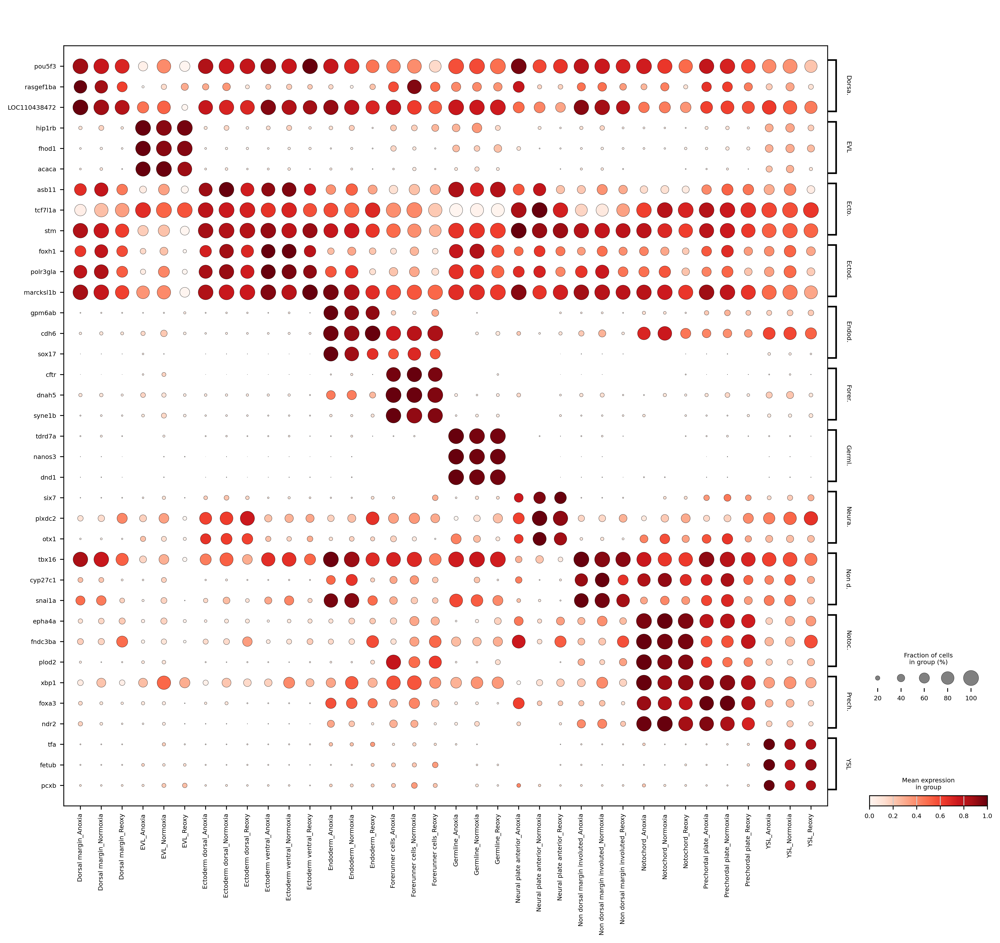

In [ ]:
import matplotlib.pyplot as plt

fig = sc.pl.dotplot(
    adata2,
    var_names=group_markers,
    groupby='cluster_group',
    standard_scale='var',
    swap_axes=True,
    show=False,
    return_fig=True
)


fig.savefig('/Plots/Marker_genes.png', dpi=600, bbox_inches='tight')
